In [2]:
!python -m pip install matplotlib seaborn
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Cargamos el archivo CSV que está en la misma carpeta
df_MET = pd.read_csv('03 minuteMETsNarrow_merged.csv', sep=',')



In [3]:


# Le pedimos a Python que nos muestre las primeras 5 filas para comprobar que todo está bien
df_MET.head()

print(df_MET['Id'].nunique())
print()
print(df_MET['Id'].unique())

33

[1503960366 1624580081 1644430081 1844505072 1927972279 2022484408
 2026352035 2320127002 2347167796 2873212765 3372868164 3977333714
 4020332650 4057192912 4319703577 4388161847 4445114986 4558609924
 4702921684 5553957443 5577150313 6117666160 6290855005 6775888955
 6962181067 7007744171 7086361926 8053475328 8253242879 8378563200
 8583815059 8792009665 8877689391]


In [4]:
df_MET.info()

<class 'pandas.DataFrame'>
RangeIndex: 1325580 entries, 0 to 1325579
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype
---  ------          --------------    -----
 0   Id              1325580 non-null  int64
 1   ActivityMinute  1325580 non-null  str  
 2   METs            1325580 non-null  int64
dtypes: int64(2), str(1)
memory usage: 30.3 MB


In [5]:
df_MET.describe()

,Id,METs
count,1.325580e+06,1.325580e+06
mean,4.847898e+09,1.469001e+01
std,2.422313e+09,1.205541e+01
min,1.503960e+09,0.000000e+00
25%,2.320127e+09,1.000000e+01
50%,4.445115e+09,1.000000e+01
75%,6.962181e+09,1.100000e+01
max,8.877689e+09,1.570000e+02


In [6]:
# Convertimos la columna ActivityMinute a un tipo de dato datetime formal
df_MET['ActivityMinute'] = pd.to_datetime(df_MET['ActivityMinute'], format='%m/%d/%Y %I:%M:%S %p')

# Verificamos que el cambio se haya realizado examinando los tipos de datos
df_MET.info()

<class 'pandas.DataFrame'>
RangeIndex: 1325580 entries, 0 to 1325579
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   Id              1325580 non-null  int64         
 1   ActivityMinute  1325580 non-null  datetime64[us]
 2   METs            1325580 non-null  int64         
dtypes: datetime64[us](1), int64(2)
memory usage: 30.3 MB


In [7]:
# Extraemos la hora (0 a 23) para ver el comportamiento a lo largo del día
df_MET['Hora'] = df_MET['ActivityMinute'].dt.hour

# Extraemos el nombre del día de la semana
df_MET['Dia_Semana'] = df_MET['ActivityMinute'].dt.day_name()

# Mostramos un vistazo para confirmar las nuevas columnas
df_MET.head()

,Id,ActivityMinute,METs,Hora,Dia_Semana
0,1503960366,2016-04-12 00:00:00,10,0,Tuesday
1,1503960366,2016-04-12 00:01:00,10,0,Tuesday
2,1503960366,2016-04-12 00:02:00,10,0,Tuesday
3,1503960366,2016-04-12 00:03:00,10,0,Tuesday
4,1503960366,2016-04-12 00:04:00,10,0,Tuesday


  Dia_Semana      METs
0     Monday  1.466298
1    Tuesday  1.487975
2  Wednesday  1.460778
3   Thursday  1.466916
4     Friday  1.473096
5   Saturday  1.503333
6     Sunday  1.421722


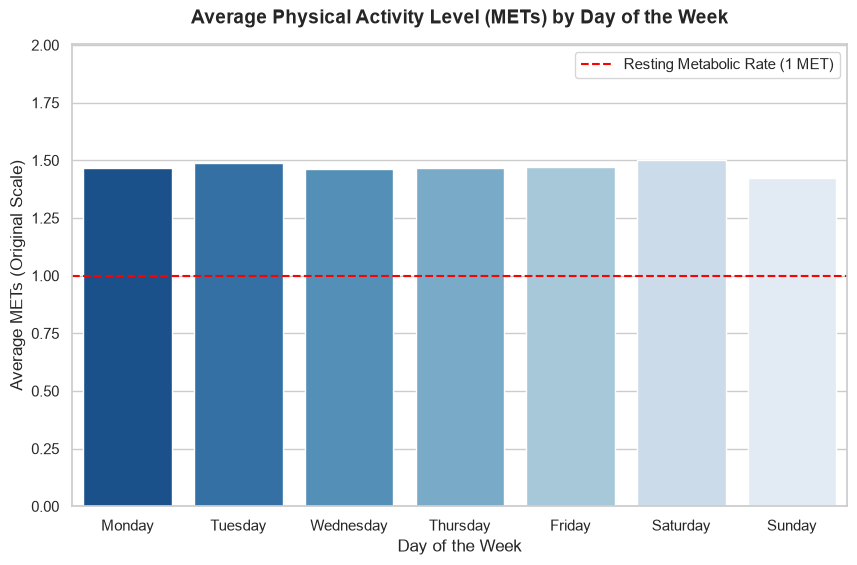

In [8]:
# 1. Definimos el orden lógico de los días en inglés (tal como los extrae .day_name())
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 2. Agrupamos por día de la semana y calculamos el promedio de METs
df_dias = (
    df_MET.groupby('Dia_Semana')['METs'].mean()/10
    ).reindex(orden_dias).reset_index()
print(df_dias.head(7))

# 3. Configuramos el estilo de la gráfica
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 4. Creamos la gráfica de barras con un color azul amigable
ax = sns.barplot(x='Dia_Semana', y='METs', data=df_dias, palette='Blues_r', hue='Dia_Semana', legend=False)

# 5. Agregamos la línea de referencia de reposo absoluto (10 significa 1 MET)
plt.axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='Resting Metabolic Rate (1 MET)')

# 6. Personalizamos títulos y etiquetas estilo Bellabeat
plt.title('Average Physical Activity Level (METs) by Day of the Week',fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Average METs (Original Scale)', fontsize=12)
plt.ylim(0, df_dias['METs'].max() + 0.5) # Le damos un poco de espacio arriba a la gráfica
plt.legend()

# Mostramos la gráfica
plt.show()


In [9]:
# Creamos una serie base vacía o con un texto por defecto
df_MET['Week_or_Weekend'] = 'Desconocido'
print(df_MET.head())
print(df_MET.info())

# Definimos las condiciones directamente asociadas a sus respuestas
df_MET['Week_or_Weekend'] = df_MET['Week_or_Weekend'].case_when([
    (df_MET['Dia_Semana'].isin(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']), 'Weekday'),
    (df_MET['Dia_Semana'] == 'Saturday', 'Saturday'),
    (df_MET['Dia_Semana'] == 'Sunday', 'Sunday')
])


           Id      ActivityMinute  METs  Hora Dia_Semana Week_or_Weekend
0  1503960366 2016-04-12 00:00:00    10     0    Tuesday     Desconocido
1  1503960366 2016-04-12 00:01:00    10     0    Tuesday     Desconocido
2  1503960366 2016-04-12 00:02:00    10     0    Tuesday     Desconocido
3  1503960366 2016-04-12 00:03:00    10     0    Tuesday     Desconocido
4  1503960366 2016-04-12 00:04:00    10     0    Tuesday     Desconocido
<class 'pandas.DataFrame'>
RangeIndex: 1325580 entries, 0 to 1325579
Data columns (total 6 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   Id               1325580 non-null  int64         
 1   ActivityMinute   1325580 non-null  datetime64[us]
 2   METs             1325580 non-null  int64         
 3   Hora             1325580 non-null  int32         
 4   Dia_Semana       1325580 non-null  str           
 5   Week_or_Weekend  1325580 non-null  str           
dtypes: datetime64[us

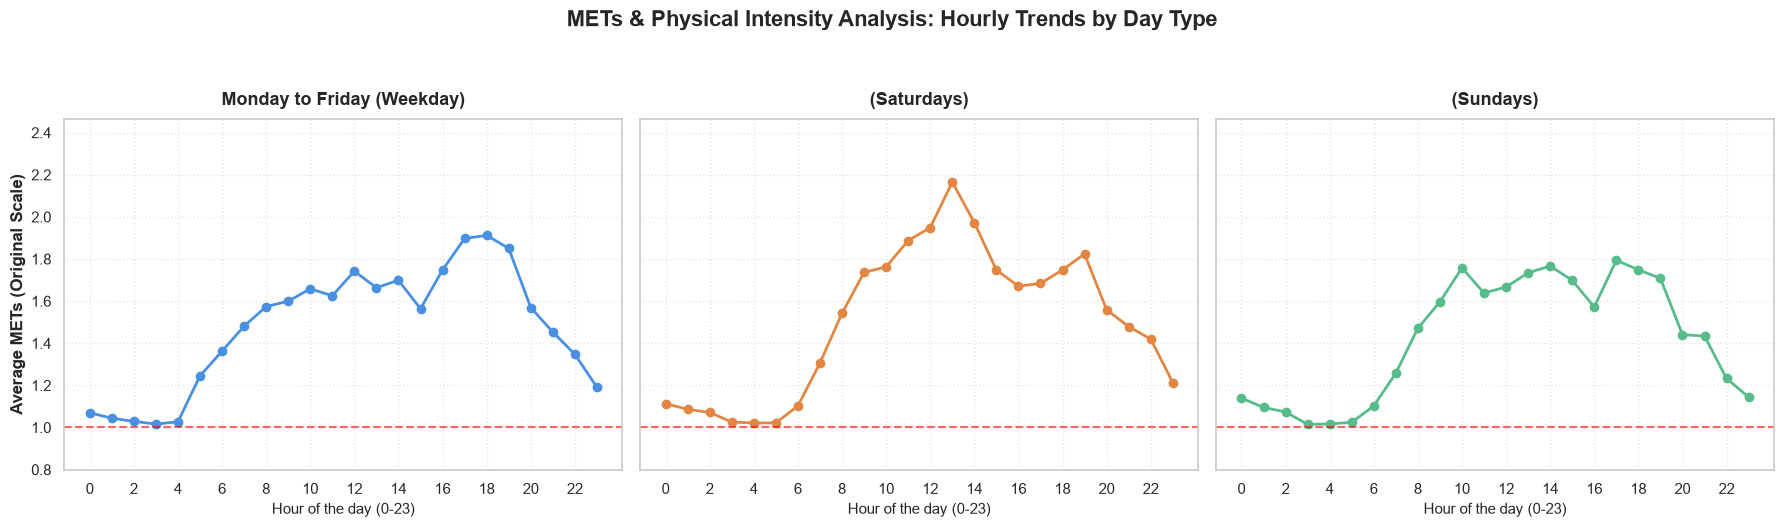

In [10]:

# 1. Agrupamos los datos por Tipo de Día y Hora, calculando el promedio de METs transformado (escala real)
# Nota: Dividimos entre 10 para corregir la escala de Fitbit (donde 10 = 1 MET)
df_grouped = df_MET.groupby(['Week_or_Weekend', 'Hora'])['METs'].mean().unstack(level=0) / 10



# 2. Configurar la estructura de la gráfica (1 fila con 3 subgráficas de forma horizontal)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Lista de las categorías, títulos y colores ejecutivos que usaremos
categorias = ['Weekday', 'Saturday', 'Sunday']
titulos = ['Monday to Friday (Weekday)', '(Saturdays)', '(Sundays)']
colores = ['#4A90E2', '#E28743', '#57BB8A']  # Azul, Naranja, Verde

# 3. Crear cada gráfica usando un ciclo para mantener el código limpio
for i, cat in enumerate(categorias):
    ax = axes[i]
    
    # Graficar la línea de comportamiento horario
    ax.plot(df_grouped.index, df_grouped[cat], marker='o', color=colores[i], linewidth=2, label=cat)
    
    # Línea de referencia horizontal en y = 1 (Reposo absoluto / Tasa metabólica basal)
    ax.axhline(y=1, color='red', linestyle='--', alpha=0.6, label='Reposo (1 MET)')
    
    # Títulos y formato de ejes individuales
    ax.set_title(titulos[i], fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Hour of the day (0-23)', fontsize=11)
    ax.set_xticks(range(0, 24, 2))  # Muestra las horas de 2 en 2 para que no se amontone
    ax.grid(axis='both', linestyle=':', alpha=0.5)

# Ajustes globales del eje Y (compartido por los 3 gráficos gracias a sharey=True)
axes[0].set_ylabel('Average METs (Original Scale)', fontsize=12, fontweight='bold')

# Límites del eje Y para que el gráfico "respire" y no toque los bordes
max_val = df_grouped.max().max()
axes[0].set_ylim(0.8, max_val + 0.3)

# Título principal del reporte ejecutivo
plt.suptitle('METs & Physical Intensity Analysis: Hourly Trends by Day Type', fontsize=16, fontweight='bold', y=1.05)

# Ajustar diseño de forma automática y mostrar
plt.tight_layout()
plt.show()

  Dia_Semana    METs
0     Monday  171660
1    Tuesday  216000
2  Wednesday  212820
3   Thursday  196620
4     Friday  179820
5   Saturday  174900
6     Sunday  173760


C:\Users\andre\AppData\Local\Temp\ipykernel_2932\509055009.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


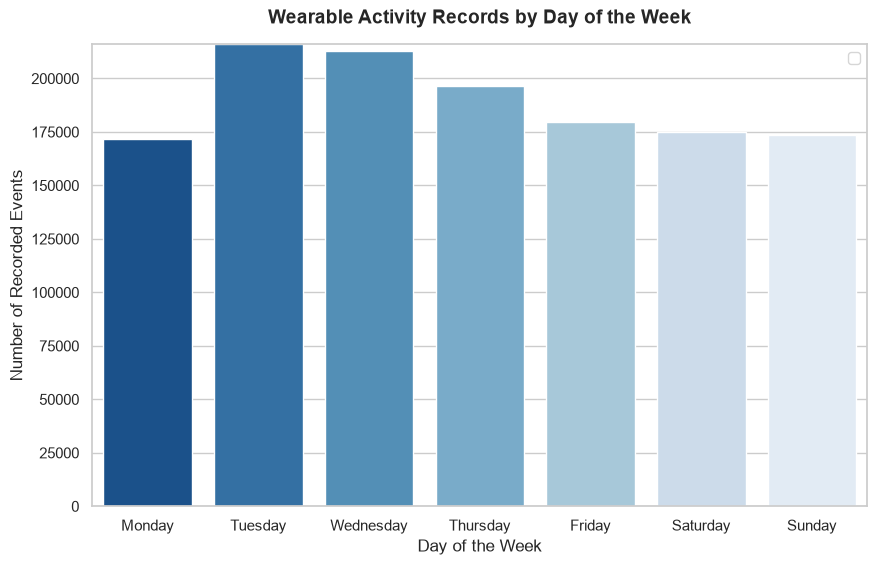

In [11]:
# Se quiere dentificar el "churn" o abandono del dsipositivo dutante la semana.

df_wearing = (
    df_MET.groupby('Dia_Semana')['METs'].count()
    ).reindex(orden_dias).reset_index()
print(df_wearing.head(7))

# 3. Configuramos el estilo de la gráfica
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 4. Creamos la gráfica de barras con un color azul amigable
ax = sns.barplot(x='Dia_Semana', y='METs', data=df_wearing, palette='Blues_r', hue='Dia_Semana', legend=False)

# # 5. Agregamos la línea de referencia de reposo absoluto (10 significa 1 MET)
# plt.axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='Resting Metabolic Rate (1 MET)')

# 6. Personalizamos títulos y etiquetas estilo Bellabeat
plt.title('Wearable Activity Records by Day of the Week',fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Number of Recorded Events', fontsize=12)
plt.ylim(0, df_wearing['METs'].max() + 0.5) # Le damos un poco de espacio arriba a la gráfica
plt.legend()

# Mostramos la gráfica
plt.show()


   DayType  Hour  AverageMETs
0  Weekday     0        1.069
1  Weekday     1        1.044
2  Weekday     2        1.029
3  Weekday     3        1.016
4  Weekday     4        1.027
5  Weekday     5        1.247
6  Weekday     6        1.361
7  Weekday     7        1.479
8  Weekday     8        1.568
9  Weekday     9        1.595

<class 'pandas.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   DayType      72 non-null     category
 1   Hour         72 non-null     int32   
 2   AverageMETs  72 non-null     float64 
dtypes: category(1), float64(1), int32(1)
memory usage: 1.2 KB
None


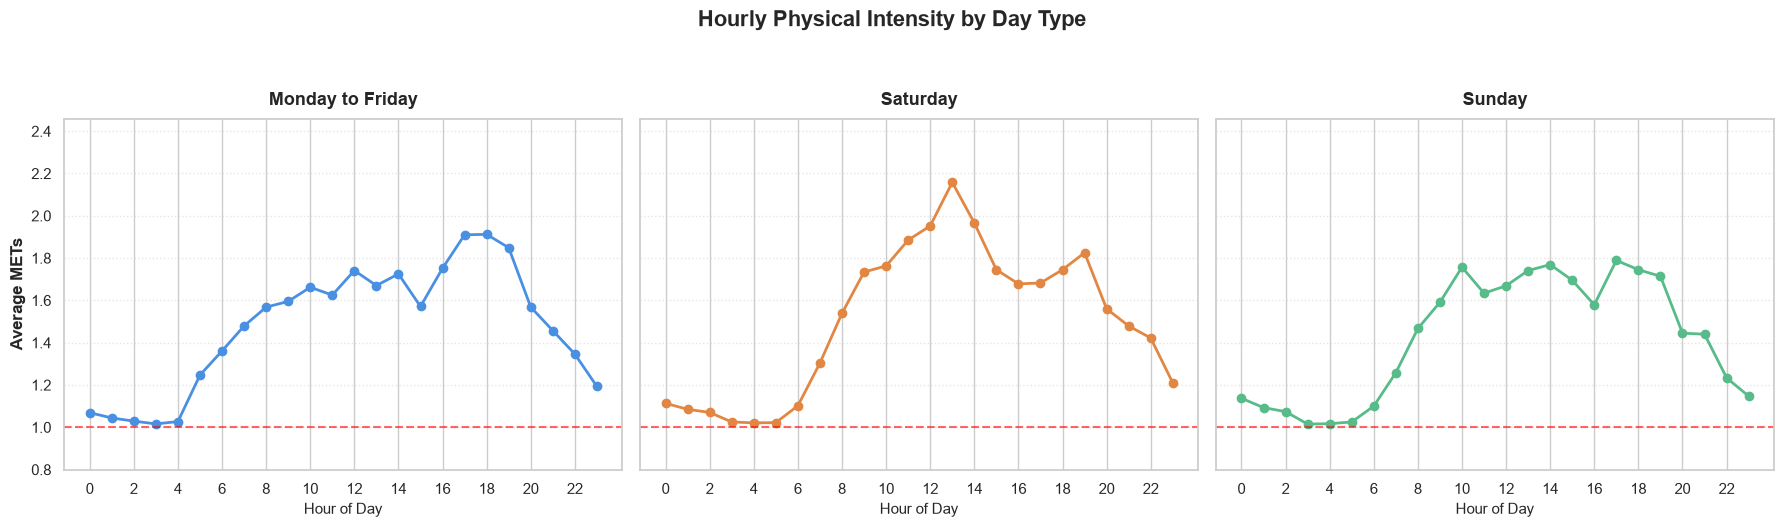

In [12]:
# =============================================================================
# Hourly METs Summary by Day Type
# =============================================================================

# 1. Create a copy to preserve the original dataset
df_mets_hourly = df_MET.copy()

# 2. Convert the date-time field to datetime
# Replace 'ActivityMinute' if your date-time column has another name
df_mets_hourly['ActivityMinute'] = pd.to_datetime(
    df_mets_hourly['ActivityMinute']
)

# 3. Extract the calendar date and hour
df_mets_hourly['ActivityDate'] = (
    df_mets_hourly['ActivityMinute']
    .dt.date
)

df_mets_hourly['Hour'] = (
    df_mets_hourly['ActivityMinute']
    .dt.hour
)

# 4. Calculate average METs for each specific date and hour
# Division by 10 converts the stored Fitbit scale to the real MET scale
daily_hourly_mets = (
    df_mets_hourly
    .groupby(
        ['ActivityDate', 'Week_or_Weekend', 'Hour'],
        as_index=False
    )['METs']
    .mean()
)

daily_hourly_mets['AverageMETs'] = (
    daily_hourly_mets['METs'] / 10
)

daily_hourly_mets = daily_hourly_mets.drop(
    columns='METs'
)

# 5. Calculate the average across dates for each day type and hour
hourly_mets_summary = (
    daily_hourly_mets
    .groupby(
        ['Week_or_Weekend', 'Hour'],
        as_index=False
    )['AverageMETs']
    .mean()
)

# 6. Rename the category field for clearer use in Tableau
hourly_mets_summary = hourly_mets_summary.rename(
    columns={
        'Week_or_Weekend': 'DayType'
    }
)

# 7. Apply the desired category order
day_type_order = [
    'Weekday',
    'Saturday',
    'Sunday'
]

hourly_mets_summary['DayType'] = pd.Categorical(
    hourly_mets_summary['DayType'],
    categories=day_type_order,
    ordered=True
)

hourly_mets_summary = (
    hourly_mets_summary
    .sort_values(['DayType', 'Hour'])
    .reset_index(drop=True)
)

# 8. Round values for display
hourly_mets_summary['AverageMETs'] = (
    hourly_mets_summary['AverageMETs']
    .round(3)
)

# 9. Validate the output
print(hourly_mets_summary.head(10))
print()
print(hourly_mets_summary.info())

# 10. Export the prepared table for Tableau
hourly_mets_summary.to_csv(
    '03_hourly_mets_summary.csv',
    index=False
)

# =============================================================================
# Python Visualization
# =============================================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    sharey=True
)

categories = [
    'Weekday',
    'Saturday',
    'Sunday'
]

titles = [
    'Monday to Friday',
    'Saturday',
    'Sunday'
]

colors = [
    '#4A90E2',
    '#E28743',
    '#57BB8A'
]

for i, category in enumerate(categories):

    ax = axes[i]

    category_data = hourly_mets_summary[
        hourly_mets_summary['DayType'] == category
    ]

    ax.plot(
        category_data['Hour'],
        category_data['AverageMETs'],
        marker='o',
        color=colors[i],
        linewidth=2,
        label=category
    )

    # Reference line representing 1 MET
    ax.axhline(
        y=1,
        color='red',
        linestyle='--',
        alpha=0.6,
        label='Resting Level (1 MET)'
    )

    ax.set_title(
        titles[i],
        fontsize=13,
        fontweight='bold',
        pad=10
    )

    ax.set_xlabel(
        'Hour of Day',
        fontsize=11
    )

    ax.set_xticks(
        range(0, 24, 2)
    )

    ax.grid(
        axis='y',
        linestyle=':',
        alpha=0.5
    )

axes[0].set_ylabel(
    'Average METs',
    fontsize=12,
    fontweight='bold'
)

max_value = hourly_mets_summary['AverageMETs'].max()

axes[0].set_ylim(
    0.8,
    max_value + 0.3
)

plt.suptitle(
    'Hourly Physical Intensity by Day Type',
    fontsize=16,
    fontweight='bold',
    y=1.05
)

plt.tight_layout()
plt.show()
